# Imports

In [1]:
from data import *
from models import *
from optim import *
from results_utils import *
from scripts import *
from trainer import *

In [2]:
OPTIMIZE = False
VAL_SIZE = 48
TRAINING = True
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Using device: {DEVICE}")

Using device: mps


# Load Data

In [3]:
# Data parameters
T = 200        
d = 5         
n_train = 64
n_test = 128
sigma = 5  
n_clusters = 5
rng = np.random.default_rng(42)

# Homogeneous data
tau = 15.
thetas, theta0, (X_tr, y_tr), (X_te, y_te) = generate_tasks(
    T=T, d=d, n_train=n_train, n_test=n_test,
    tau=tau, sigma=sigma, rng=rng
)
X_train = {i: X_tr[i] for i in range(len(X_tr))}
y_train = {i: y_tr[i] for i in range(len(y_tr))}
X_test = {i: X_te[i] for i in range(len(X_te))}
y_test = {i: y_te[i] for i in range(len(y_te))}

# Clustered data
tau_within, tau_between = 5., 10.
thetas_c, theta_global, cluster_centers, (X_tr_c, y_tr_c), (X_te_c, y_te_c), cluster_ids = generate_clustered_tasks(
    T=T, d=d, n_train=n_train, n_test=n_test,
    n_clusters=n_clusters, tau_within=tau_within, tau_between=tau_between,
    sigma=sigma, rng=rng
)
X_train_c = {i: X_tr_c[i] for i in range(len(X_tr_c))}
y_train_c = {i: y_tr_c[i] for i in range(len(y_tr_c))}
X_test_c = {i: X_te_c[i] for i in range(len(X_te_c))}
y_test_c = {i: y_te_c[i] for i in range(len(y_te_c))}

# Optimization

### Clustered data

In [4]:
if OPTIMIZE:
    nodes = list(X_train_c.keys())
    model_class = "linear"
    B = 1000

    optim_space = {
        "eta": ("loguniform", 0.001, 0.1),
        "b_proto_frac": ("uniform", 0.1, 0.9),
    }

    # Run optimization
    best_params_clustered = optimize_synthetic_dataset(
        X_train_c, y_train_c, X_test_c, y_test_c, nodes, VAL_SIZE, DEVICE, model_class, B, optim_space, n_trials=50
    )

    print("Best parameters for clustered dataset:", best_params_clustered)

# Sweep experiment

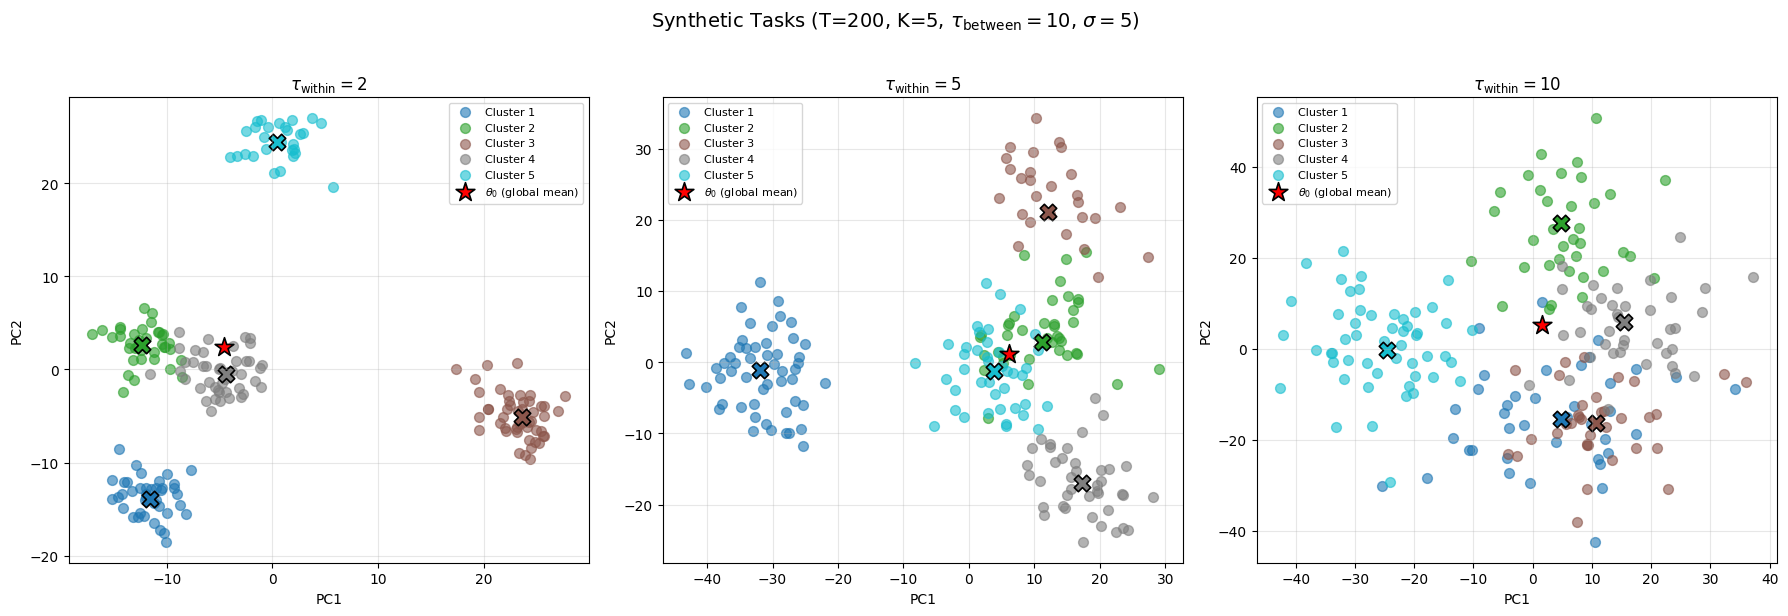

In [5]:
fig, axs = plot_clustered_tasks_2d(
    tau_within_values=[2, 5, 10],
    tau_between=10,
    n_clusters=5,
    sigma=5
)
plt.savefig("synthetic_tasks.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [6]:
# Run sweep experiments with tau
Ts = (200,)
Bs = (500,)
taus = (10,)
n_clusters = 5
reps = 5
mst_distance_types = ("gradient", "model", "mean_cov_feature")

d = 3
sigma = 5.
n_train, n_test = 64, 128
all_results_iid = {}
all_results_clust = {}

lr = .00121423383766747
b_proto_frac = .2791730181429596

all_results_clust = {}
for tau in taus:
    print(f"\nRunning tau={tau} with MST variants...")
    methods, results = run_sweep_experiment_with_mst_variants(
        Ts=Ts, Bs=Bs, d=d, n_train=n_train, n_test=n_test,
        tau=tau, sigma=sigma, lr=lr, reps=reps,  # Small test
        clustered=True, n_clusters=n_clusters, tau_between=10,
        seed_fraction=b_proto_frac,
        model_class="linear",
        mst_distance_types=mst_distance_types,
        debug_first_rep=False, 
    )

    all_results_clust[tau] = results
    
    print_statistical_comparison(results, methods, Ts, Bs)


Running tau=10 with MST variants...

Running T=200, B=500, source_mode=medoid
Generating 5 datasets for T=200, B=500...
Data generation complete. Running experiments...
  rep 1/5 | Indiv=953.5, Star=913.1, Rand=737.4, MST[gradient=770.7, model=661.7, mean_cov_feature=866.9]
  rep 2/5 | Indiv=1159.7, Star=1078.0, Rand=1424.8, MST[gradient=1060.7, model=776.8, mean_cov_feature=1024.7]
  rep 3/5 | Indiv=1107.2, Star=984.2, Rand=850.8, MST[gradient=862.9, model=925.7, mean_cov_feature=1161.5]
  rep 4/5 | Indiv=1080.7, Star=1374.5, Rand=1088.9, MST[gradient=841.4, model=916.8, mean_cov_feature=1012.0]
  rep 5/5 | Indiv=1025.0, Star=991.2, Rand=1130.3, MST[gradient=1033.1, model=745.2, mean_cov_feature=995.6]

STATISTICAL COMPARISON (vs Indiv)

T=200, B=500
------------------------------------------------------------
Star                : p=0.9700     d=-0.020 (base=1065.2, method=1068.2)
CTL-RandTree        : p=0.8574     d=+0.096 (base=1065.2, method=1046.5)
CTL-MST-gradient    : p=0.0337

In [7]:
# Generate LaTeX table
latex_str, df = sweep_results_to_latex_unified(
    all_results_clust,
    methods, Ts, Bs, taus,
    caption="Test MSE across $T$, $B$, and $\\tau$ (mean $\pm$ std, best in bold, second underlined)",
    label="tab:sweep_regression",
    show_std=True,
)

print("\n" + "="*60)
print("LATEX TABLE")
print("="*60)
print(latex_str)

# Save to file
with open("results_regression_sweep.tex", "w") as f:
    f.write(latex_str)


LATEX TABLE
\begin{table}[ht]
\centering
\small
\resizebox{\textwidth}{!}{
\begin{tabular}{ccc|cccccc}
\toprule
 &  &  &  &  &  & \multicolumn{3}{c}{MST Variants} \\
\cmidrule(lr){7-9}
$\tau$ & $T$ & $B$ & \rotatebox{45}{Indiv} & \rotatebox{45}{Star} & \rotatebox{45}{RandTree} & \rotatebox{45}{gradient} & \rotatebox{45}{model} & \rotatebox{45}{mean_cov_feature} \\
\midrule
10 & 200 & 500 & $1065.2 \pm 70.7$ & $1068.2 \pm 161.8$ & $1046.5 \pm 239.1$ & $\underline{913.8 \pm 113.2}$ & $\mathbf{805.3 \pm 101.9}$ & $1012.1 \pm 93.6$ \\
\bottomrule
\end{tabular}
}
\caption{Test MSE across $T$, $B$, and $\tau$ (mean $\pm$ std, best in bold, second underlined)}
\label{tab:sweep_regression}
\end{table}


In [8]:
# keep all methods but MST-feature for all tau values
all_results_clust_filtered = {}
methods_filtered = [m for m in methods if m != "CTL-MST-feature"]   
for tau in taus:
    all_results_clust_filtered[tau] = {
        m: all_results_clust[tau][m]
        for m in methods_filtered
    }


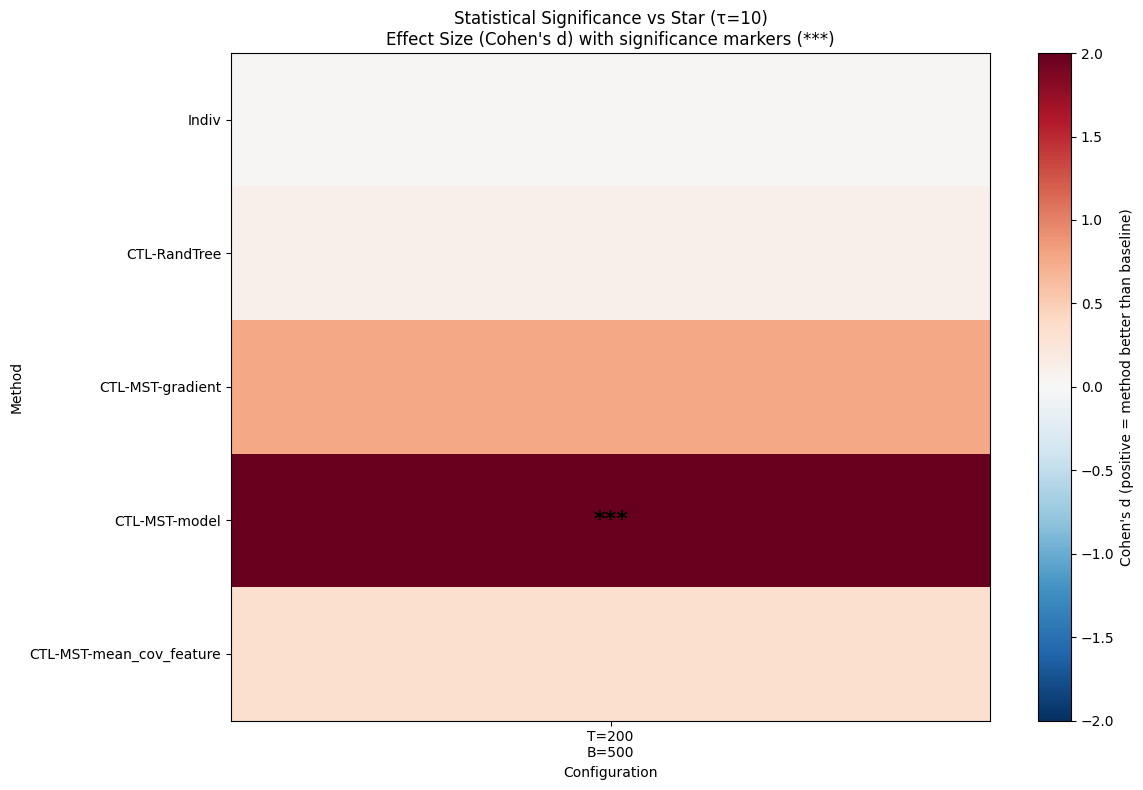

In [9]:
tau_values = [10]   # or [2.0, 5.0, 10.0] depending on your keys
tau_focus = tau_values[0] 
fig, ax = plot_significance_matrix(
    results=all_results_clust_filtered[tau_focus],
    tau_focus=tau_focus,
    methods=methods_filtered,
    Ts=Ts,
    Bs=Bs,
    baseline="Star",
    alpha=0.05,
    figsize=(12, 8)
)
plt.tight_layout()
plt.savefig(f"significance_matrix_clust_tau{tau_focus}.pdf", bbox_inches='tight', dpi=300)
plt.show()


In [10]:
# Check the DataFrame
print("DataFrame columns:", df.columns.tolist())
print("\nDataFrame head:")
print(df.head())

DataFrame columns: ['tau', 'T', 'B', 'Indiv_formatted', 'Star_formatted', 'CTL-RandTree_formatted', 'CTL-MST-gradient_formatted', 'CTL-MST-model_formatted', 'CTL-MST-mean_cov_feature_formatted']

DataFrame head:
   tau    T    B    Indiv_formatted      Star_formatted  \
0   10  200  500  $1065.2 \pm 70.7$  $1068.2 \pm 161.8$   

  CTL-RandTree_formatted     CTL-MST-gradient_formatted  \
0     $1046.5 \pm 239.1$  $\underline{913.8 \pm 113.2}$   

      CTL-MST-model_formatted CTL-MST-mean_cov_feature_formatted  
0  $\mathbf{805.3 \pm 101.9}$                  $1012.1 \pm 93.6$  


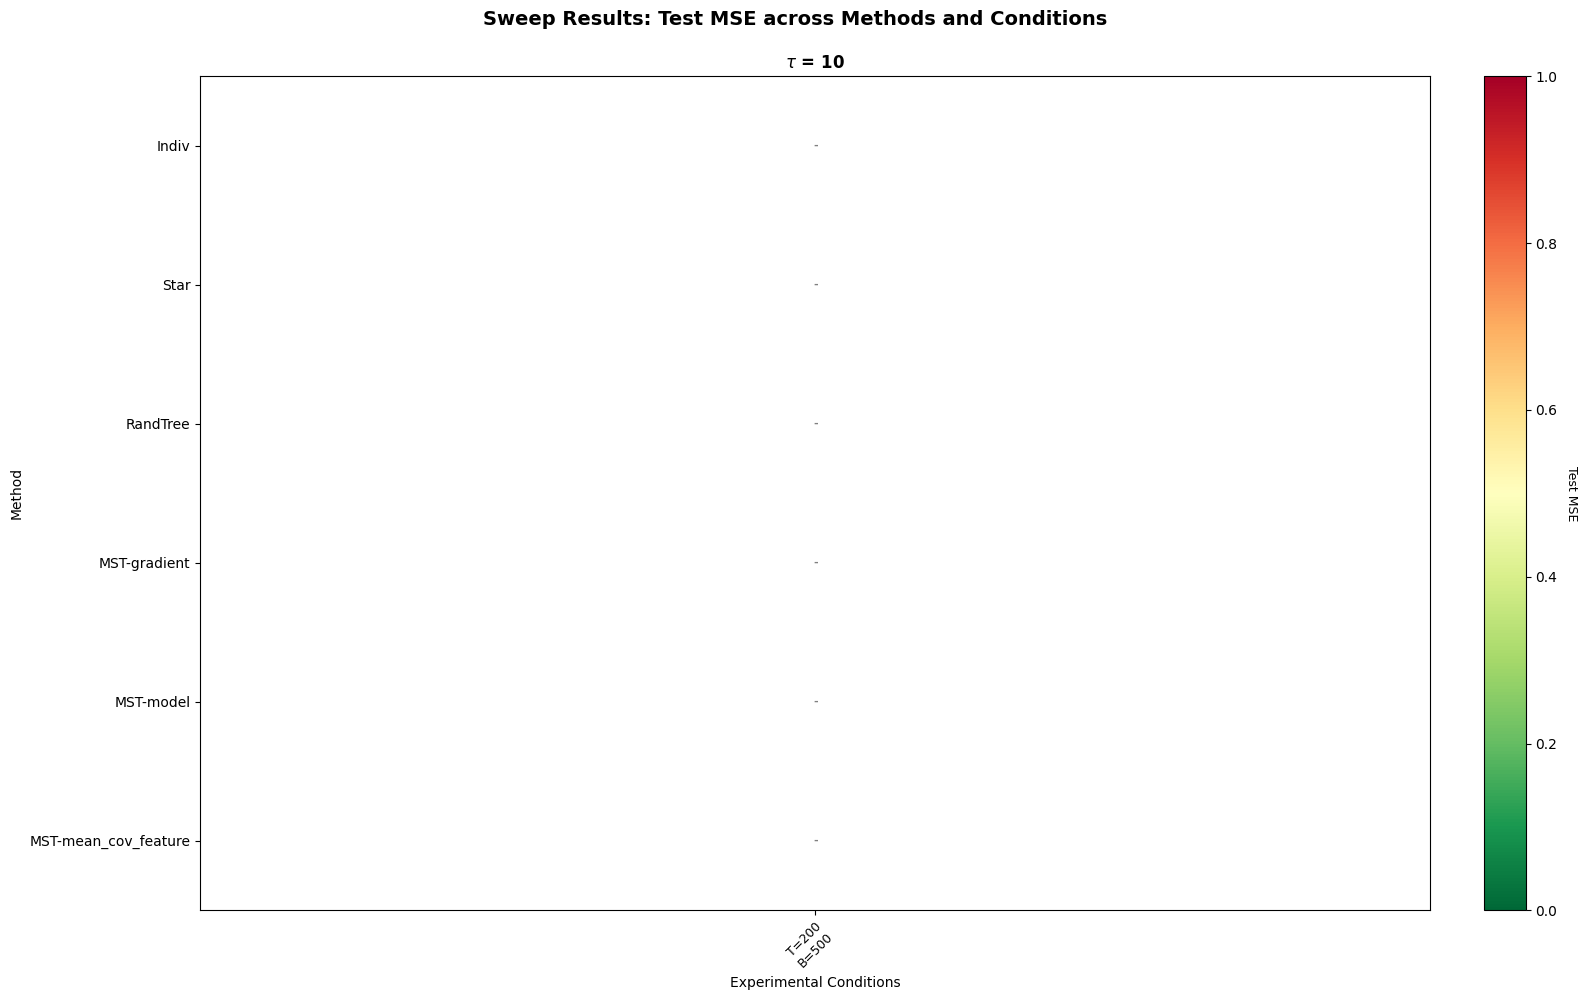

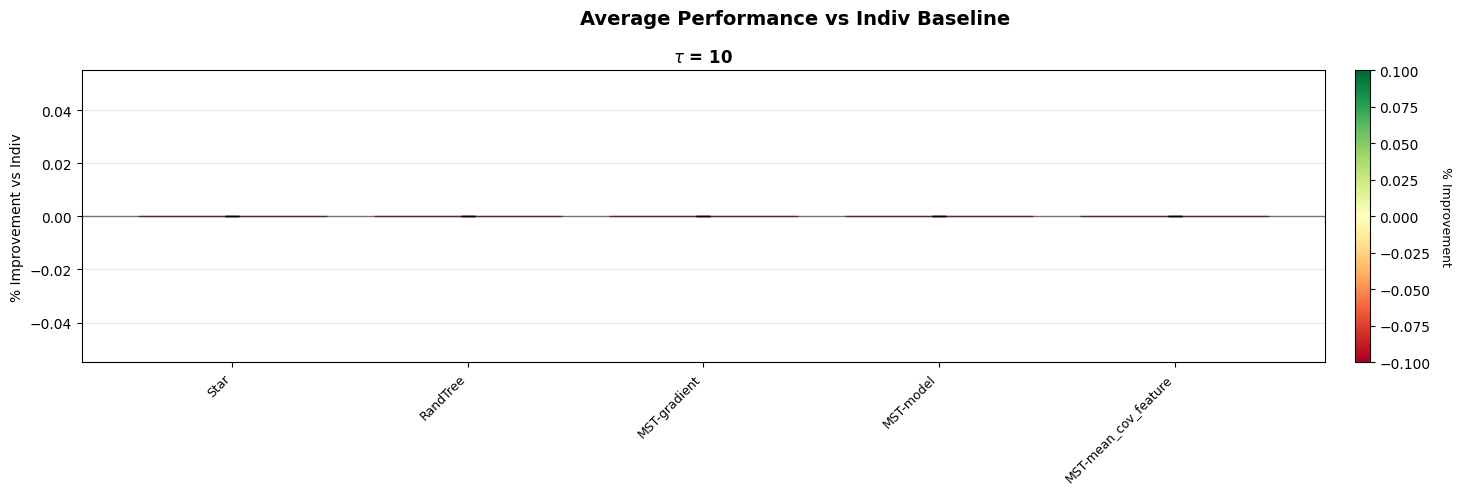

In [11]:
# Visualization 1: Heatmap view

COLORS_EXTENDED = {
    "Indiv": "gray",
    "Star": "blue",
    "CTL-RandTree": "green",
    "CTL-MST-feature": "red",
    "CTL-MST-target": "orange",
    "CTL-MST-gradient": "purple",
    "CTL-MST-model": "brown",
    "CTL-MST-kl": "pink",
    "CTL-MST-wasserstein": "cyan",
    "CTL-MST-mean_cov_feature": "olive",
}


fig1, axes1 = visualize_sweep_results_table(
    df=df,
    methods=methods_filtered,
    taus=taus,
    Ts=Ts,
    Bs=Bs,
    colors=COLORS_EXTENDED,
    figsize=(16, 10),
    show_std=False,
    normalize_per_condition=False,  # Set True to show % above best
)
plt.savefig("sweep_results_heatmap.pdf", bbox_inches='tight', dpi=300)
plt.show()

# Visualization 2: Bar chart comparing to baseline
fig2, axes2 = visualize_sweep_results_bars(
    df=df,
    methods=methods_filtered,
    taus=taus,
    Ts=Ts,
    Bs=Bs,
    colors=COLORS_EXTENDED,
    figsize=(16, 5),
    baseline="Indiv",
)
plt.savefig("sweep_results_bars.pdf", bbox_inches='tight', dpi=300)
plt.show()

PARSING LATEX TABLE
Extracted 16 data rows

Found 10 unique (dataset, budget) combinations:
  CIFAR        B=500
  CIFAR        B=2000
  FMNIST       B=500
  FMNIST       B=2000
  Syn          B=500
  Syn          B=1000
  Syn          B=2000
  UK           B=500
  UK           B=1000
  UK           B=2000

GROUPED BY (PROBLEM, BUDGET)
Synthetic  | B=500  | rmse | n_configs=3
Synthetic  | B=1000 | rmse | n_configs=3
Synthetic  | B=2000 | rmse | n_configs=3
UK         | B=500  | rmse | n_configs=1
UK         | B=1000 | rmse | n_configs=1
UK         | B=2000 | rmse | n_configs=1
Image      | B=500  | acc  | n_configs=2
Image      | B=2000 | acc  | n_configs=2

POLYGON DATA
Indiv: 8 vertices
CTL-RandTree: 8 vertices
CTL-MST: 8 vertices

 Creating radar plot...
   Datasets: ['Image', 'Synthetic', 'UK']
   Budgets: [500, 1000, 2000]
   Vertices: 8

   Best MST method at each vertex:
     Image      B=500  → Gradient
     Image      B=2000 → Gradient
     Synthetic  B=500  → Model
     Synth

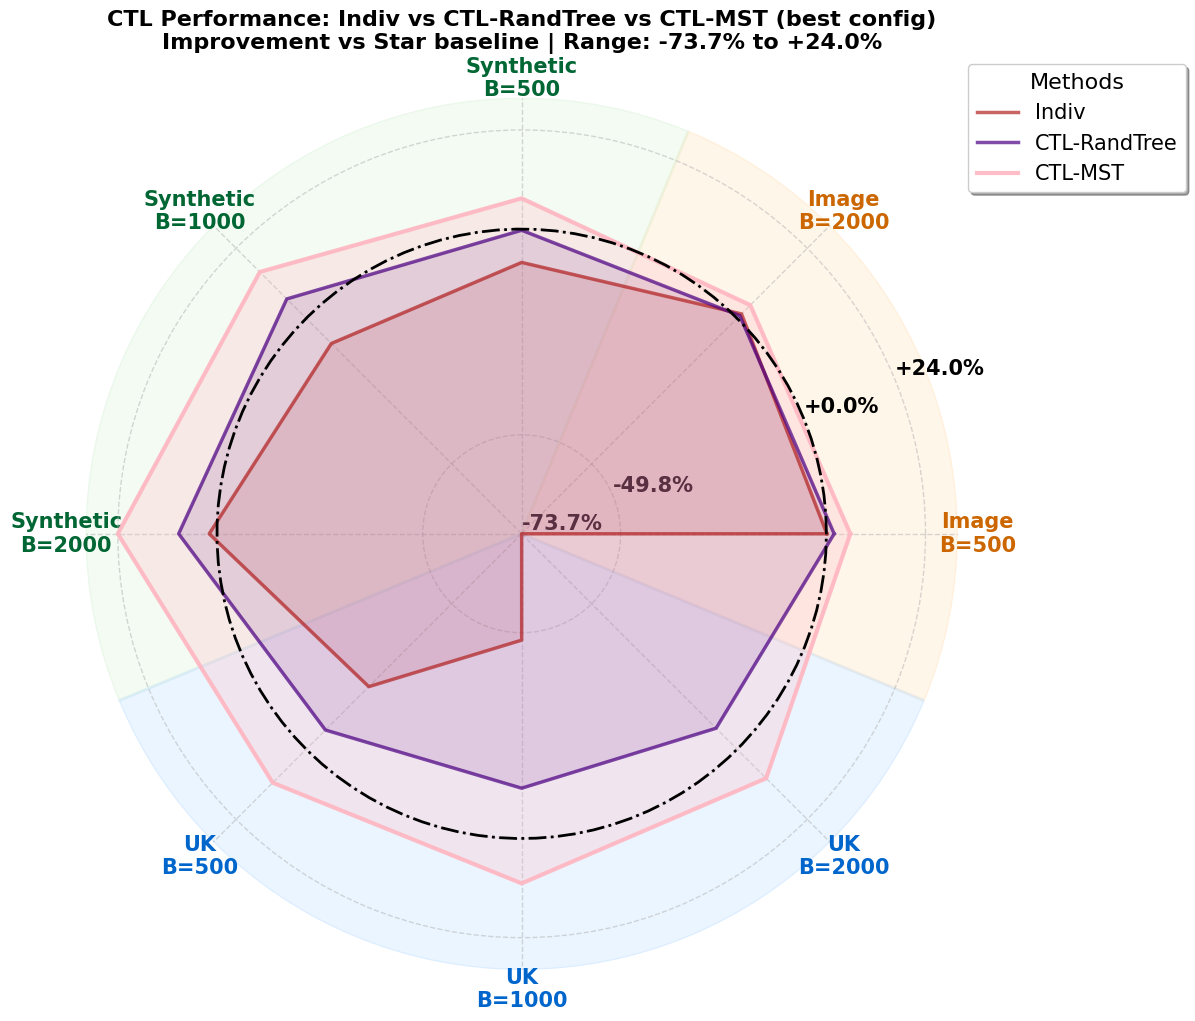

Saved radar plot to radar_three_polygons.pdf


In [12]:
# =========================================================
# Config
# =========================================================

METHODS = [
    "Indiv", "Star", "CTL-RandTree",
    "Feature", "Target", "Gradient", "Model",
    "KL", "Wasserstein", "MMD", "MeanCov", "JS", "CKA"
]

# MST methods (to be averaged)
MST_METHODS = [
    "Feature", "Target", "Gradient", "Model",
    "KL", "Wasserstein", "MMD", "MeanCov", "JS", "CKA"
]

# =========================================================
# 1) Robust LaTeX parsing
# =========================================================

_LATEX_WRAPPERS = [
    (r"\\mathbf\{", ""),
    (r"\\underline\{", ""),
    (r"\}", ""),
]

def _clean_cell(cell: str) -> str:
    """Remove simple LaTeX wrappers and $ signs."""
    s = cell.strip()
    s = s.replace("$", "")
    for pat, rep in _LATEX_WRAPPERS:
        s = re.sub(pat, rep, s)
    return s.strip()

def _extract_mean(cell: str):
    """
    Extract the mean from a cell like:
      494.2 \\pm 149.9
    possibly wrapped with \\mathbf{...} or \\underline{...}.
    Returns float or None.
    """
    s = _clean_cell(cell)
    m = re.search(r"([-+]?\d+(?:\.\d+)?)\s*\\pm", s)
    if m:
        return float(m.group(1))
    return None

def parse_multiline_table(tex_str: str):
    """
    Parse table rows split across multiple lines.
    Returns: list of dicts: {
        "dataset": str,
        "budget": int (extracted from column B),
        "values": np.array shape (13,)
    }
    """
    rows = []
    buffer = []

    for raw in tex_str.splitlines():
        line = raw.strip()

        if not line or line.startswith("%"):
            continue
        if any(tok in line for tok in ["\\toprule", "\\midrule", "\\bottomrule", "\\multicolumn"]):
            continue

        # accumulate potential row chunks
        if "&" in line:
            buffer.append(line)

        if "\\\\" in line and buffer:
            full = " ".join(buffer)
            buffer = []

            # Now parse full row
            cells = [c.strip() for c in full.replace("\\\\", "").split("&")]
            if len(cells) < 4 + len(METHODS):
                continue

            dataset = _clean_cell(cells[0])
            
            # Extract budget from column B (index 3)
            budget_str = _clean_cell(cells[3])
            try:
                budget = int(budget_str)
            except:
                continue
            
            method_cells = cells[4:4 + len(METHODS)]

            means = []
            ok = True
            for c in method_cells:
                v = _extract_mean(c)
                if v is None:
                    ok = False
                    break
                means.append(v)

            if ok and len(means) == len(METHODS):
                rows.append({
                    "dataset": dataset,
                    "budget": budget,
                    "values": np.array(means, dtype=float)
                })

    return rows


# =========================================================
# 2) Identify problem type + metric direction
# =========================================================

def identify_problem(dataset_name: str):
    ds = dataset_name.lower()
    if ds.startswith("syn"):
        return "Synthetic", "rmse"
    if ds.startswith("uk"):
        return "UK", "rmse"
    if ds.startswith("fmnist") or ds.startswith("cifar"):
        return "Image", "acc"
    return None, None


# =========================================================
# 3) Group by (problem, budget)
# =========================================================

def group_by_problem_budget(rows):
    """
    Returns dict: {(problem, budget): [(values, metric), ...]}
    Keeps all configurations (no averaging).
    """
    data = defaultdict(list)

    for row in rows:
        problem, metric = identify_problem(row["dataset"])
        if problem is None:
            continue
        key = (problem, row["budget"])
        data[key].append((row["values"], metric))

    return data


# =========================================================
# 4) Improvements vs Indiv baseline
# =========================================================

def compute_improvements(values, higher_is_better: bool):
    baseline = values[1]  # Star
    if higher_is_better:
        return (values - baseline) / baseline * 100.0
    else:
        return (baseline - values) / baseline * 100.0


# =========================================================
# 5) Create 3 polygons: Star, RandTree, MST-average
# =========================================================

def create_three_polygons(grouped_data):
    """
    Best configuration per (problem, budget) for:
    - Star
    - CTL-RandTree
    - MST (best distance among MST methods)

    Returns:
      polygons: dict {method: {(problem,budget): best_improvement}}
      best_mst_method: dict {(problem,budget): method_name}
    """
    polygons = {
        "Indiv": {},
        "CTL-RandTree": {},
        "CTL-MST": {}
    }
    best_mst_method = {}

    method_idx = {m: i for i, m in enumerate(METHODS)}
    star_idx = method_idx["Indiv"]
    rand_idx = method_idx["CTL-RandTree"]

    for (problem, budget), rows in grouped_data.items():
        # rows = list of (values, metric)
        star_vals = []
        rand_vals = []
        mst_vals = defaultdict(list)

        for values, metric in rows:
            higher_is_better = (metric == "acc")
            impr = compute_improvements(values, higher_is_better)

            star_vals.append(impr[star_idx])
            rand_vals.append(impr[rand_idx])

            for m in MST_METHODS:
                mst_vals[m].append(impr[method_idx[m]])

        # Best config per method
        polygons["Indiv"][(problem, budget)] = max(star_vals)
        polygons["CTL-RandTree"][(problem, budget)] = max(rand_vals)

        # Best MST config (method + value)
        best_m, best_v = max(
            ((m, max(vs)) for m, vs in mst_vals.items()),
            key=lambda x: x[1]
        )
        polygons["CTL-MST"][(problem, budget)] = best_v
        best_mst_method[(problem, budget)] = best_m

    return polygons, best_mst_method


# =========================================================
# 6) Radar plot with 3 polygons
# =========================================================

def radar_three_polygons(polygon_data, best_mst_info, out_pdf="radar_three_polygons.pdf"):
    """
    Create radar plot with 3 polygons: Star, RandTree, MST-best.
    Vertices are (Dataset, Budget) combinations.
    """
    # Auto-detect vertices from data
    all_vertices = set()
    for method, data in polygon_data.items():
        all_vertices.update(data.keys())
    
    # Extract and sort datasets and budgets
    datasets_set = set(v[0] for v in all_vertices)
    budgets_set = set(v[1] for v in all_vertices)
    
    datasets = sorted(datasets_set)
    budgets = sorted(budgets_set)
    
    print(f"\n Creating radar plot...")
    print(f"   Datasets: {datasets}")
    print(f"   Budgets: {budgets}")
    
    # Build vertex list
    vertices = []
    vertex_labels = []
    for dataset in datasets:
        for budget in budgets:
            if (dataset, budget) in all_vertices:
                vertices.append((dataset, budget))
                vertex_labels.append(f"{dataset}\nB={budget}")
    
    print(f"   Vertices: {len(vertices)}")
    
    # Show best MST method at each vertex
    print(f"\n   Best MST method at each vertex:")
    for vertex in vertices:
        if vertex in best_mst_info:
            print(f"     {vertex[0]:<10} B={vertex[1]:<4} → {best_mst_info[vertex]}")
    
    if len(vertices) == 0:
        print(" No vertices found!")
        return
    
    N = len(vertices)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    angles_closed = np.r_[angles, angles[0]]

    # Collect all values for normalization
    all_vals = []
    for method, data in polygon_data.items():
        for vertex in vertices:
            if vertex in data:
                all_vals.append(data[vertex])
    
    if len(all_vals) == 0:
        print(" No values found!")
        return
    
    all_vals = np.array(all_vals)
    vmin, vmax = float(all_vals.min()), float(all_vals.max())
    print(f"   Value range: {vmin:.2f}% to {vmax:.2f}%")

    def normalize(x):
        return (x - vmin) / (vmax - vmin + 1e-8)

    # Polygon styles
    polygon_styles = {
        "Indiv": {
            "color": "firebrick",
            "linewidth": 2.5,
            "alpha": 0.7,
            "fill_alpha": 0.15,
            "marker": "",
            "markersize": 7
        },
        "CTL-RandTree": {
            "color": "#4B0082",
            "linewidth": 2.5,
            "alpha": 0.7,
            "fill_alpha": 0.15,
            "marker": "",
            "markersize": 7
        },
        "CTL-MST": {
            "color": "lightpink",
            "linewidth": 3.0,
            "alpha": 0.9,
            "fill_alpha": 0.25,
            "marker": "",
            "markersize": 7
        }
    }

    # --- Create plot ---
    fig = plt.figure(figsize=(12, 12))
    ax = plt.subplot(111, polar=True)

    # Plot 3 polygons
    for method_name, data in polygon_data.items():
        # Collect values for this polygon
        vals = []
        for vertex in vertices:
            if vertex in data:
                vals.append(data[vertex])
            else:
                vals.append(0.0)  # Missing data
        
        vals_n = normalize(np.array(vals))
        vals_closed = np.r_[vals_n, vals_n[0]]

        style = polygon_styles[method_name]
        
        # Plot line
        ax.plot(
            angles_closed,
            vals_closed,
            linewidth=style["linewidth"],
            color=style["color"],
            alpha=style["alpha"],
            marker=style["marker"],
            markersize=style["markersize"],
            label=method_name,
            zorder=10 if method_name == "CTL-MST" else 8
        )
        
        # Fill area
        ax.fill(
            angles_closed,
            vals_closed,
            color=style["color"],
            alpha=style["fill_alpha"],
            zorder=5
        )

    # Axis labels
    ax.set_xticks(angles)
    ax.set_xticklabels(vertex_labels, fontsize=15, fontweight="bold")

    dataset_colors = {
        "Synthetic": "#006633",
        "UK": "#0066cc", 
        "Image": "#cc6600"
    }
    for i, (dataset, _) in enumerate(vertices):
        if dataset in dataset_colors:
            ax.get_xticklabels()[i].set_color(dataset_colors[dataset])

    group_colors = {
        "Synthetic": "#d1f0d1",
        "UK": "#b3d9ff",
        "Image": "navajowhite",
    }

    angle_width = 2 * np.pi / 8

    def draw_group_band(i_start, i_end, color, label, radius=1.08):
        width = (i_end - i_start + 1) * angle_width
        theta = angles[i_start] - angle_width / 2  # left boundary
        ax.bar(
            theta,
            radius,
            width=width,
            bottom=0.0,
            align="edge",
            color=color,
            alpha=0.25,
            edgecolor=color,
            linewidth=2,
            zorder=0
        )
        theta_mid = theta + width / 2
        ax.text(
            theta_mid, radius + 0.12, label,
            ha="center", va="center",
            fontsize=15, fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor=color,
                alpha=0.7,
                edgecolor="black",
                linewidth=1.2
            )
        )

    draw_group_band(0, 1, group_colors["Image"], "")
    draw_group_band(2, 4, group_colors["Synthetic"], "")
    draw_group_band(5, 7, group_colors["UK"], "")

    # add a circle in black that separaters positive from negative gains

    ax.plot(
        np.linspace(0, 2 * np.pi, 100),
        np.full(100, normalize(0.0)),
        color="black",
        linewidth=2,
        linestyle='dashdot',
        zorder=15,
        # label="No improvement"  
    )

    # Radial scale
    ticks = [0.0, 0.245, 0.755, 1.0]
    ax.set_yticks(ticks)
    ax.set_yticklabels(
        [f"{(vmin + t * (vmax - vmin)):+.1f}%" for t in ticks],
        fontsize=15,
        color="black",
        fontweight="bold",
    )
    ax.set_ylim(0, 1.08)

    ax.grid(True, linestyle="--", alpha=0.5, linewidth=1.0)
    ax.spines["polar"].set_visible(False)

    # Legend
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1., 1.05),
        frameon=True,
        fancybox=True,
        shadow=True,
        fontsize=15,
        title="Methods",
        title_fontsize=16
    )

    ax.set_title(
        "CTL Performance: Indiv vs CTL-RandTree vs CTL-MST (best config)\n"
        f"Improvement vs Star baseline | Range: {vmin:+.1f}% to {vmax:+.1f}%",
        fontsize=16,
        fontweight="bold",
        pad=35
    )

    plt.tight_layout()
    plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved radar plot to {out_pdf}")

# =========================================================
# 7) END-TO-END
# =========================================================


def main(tex_file_path: str):
    with open(tex_file_path, "r") as f:
        tex = f.read()

    rows = parse_multiline_table(tex)

    print("=" * 70)
    print("PARSING LATEX TABLE")
    print("=" * 70)
    print(f"Extracted {len(rows)} data rows")
    
    # Show unique (dataset, budget) combinations
    combos = set((r["dataset"], r["budget"]) for r in rows)
    print(f"\nFound {len(combos)} unique (dataset, budget) combinations:")
    for dataset, budget in sorted(combos):
        print(f"  {dataset:<12} B={budget}")

    # Group by (problem, budget)
    grouped = group_by_problem_budget(rows)

    print("\n" + "=" * 70)
    print("GROUPED BY (PROBLEM, BUDGET)")
    print("=" * 70)
    for (problem, budget), rows_pb in grouped.items():
        metric = rows_pb[0][1]
        print(f"{problem:<10} | B={budget:<4} | {metric:<4} | n_configs={len(rows_pb)}")

    # Create 3 polygons
    polygons, best_mst_info = create_three_polygons(grouped)
    
    print("\n" + "=" * 70)
    print("POLYGON DATA")
    print("=" * 70)
    for method_name, data in polygons.items():
        print(f"{method_name}: {len(data)} vertices")
    
    # Create radar plot
    radar_three_polygons(polygons, best_mst_info, out_pdf="radar_three_polygons.pdf")


# Run
main("final_table.tex")

In [ ]:
# Run sweep experiments with tau
Ts = (200,)
Bs = (500, 1000, 2000)
taus = (2, 5, 10)
n_clusters = 5
reps = 3
mst_distance_types = ("gradient")

d = 3
sigma = 5.
n_train, n_test = 64, 128
all_results_iid = {}
all_results_clust = {}

lr = .00121423383766747
b_proto_frac = .2791730181429596


results = run_budget_allocation_ablation_sweep(
    T=T,
    d=d,
    n_train=n_train,
    n_test=n_test,
    Bs=Bs,
    tau_withins=(2.0, 5.0, 10.0),  # Sweep over heterogeneity
    n_clusters=n_clusters,
    tau_between=10.0,
    sigma=sigma,
    lr=lr,
    seed_fraction=b_proto_frac,
    reps=reps,  
    base_seed=42,
    allocation_methods=['uniform', 'depth_increasing', 'depth_decreasing', 'edge_length'],
    alpha_values=(1.0, 2.0),
    beta_values=(1.0, 2.0),
    report_metric='mse',
)

ABLATION STUDY: Budget Allocation Schemes for CTL-MST-gradient
WITH TAU_WITHIN SWEEP
Tasks T=200, dim d=3, n_train=64, n_test=128
Clusters=5, τ_between=10.0, σ=5.0
τ_within values: (2.0, 5.0, 10.0)
Budgets: (500, 1000, 2000)
Repetitions: 3
Allocation methods: ['Uniform', 'Depth inc.(α=1.0)', 'Depth inc.(α=2.0)', 'Depth dec.(α=1.0)', 'Depth dec.(α=2.0)', 'EdgeLen(β=1.0)', 'EdgeLen(β=2.0)']

TAU_WITHIN = 2.0

  Budget B = 500
  ------------------------------------------------------------
    Rep   1/3 | Uniform=510.1 | Depth inc.(α=1.0)=381.9 | Depth inc.(α=2.0)=566.2 | Depth dec.(α=1.0)=424.4 | Depth dec.(α=2.0)=397.4 | EdgeLen(β=1.0)=502.2 | EdgeLen(β=2.0)=398.3

  Budget B = 1000
  ------------------------------------------------------------
    Rep   1/3 | Uniform=542.5 | Depth inc.(α=1.0)=692.7 | Depth inc.(α=2.0)=481.9 | Depth dec.(α=1.0)=444.7 | Depth dec.(α=2.0)=735.2 | EdgeLen(β=1.0)=405.9 | EdgeLen(β=2.0)=363.5

  Budget B = 2000
  ----------------------------------------------


ABLATION STUDY RESULTS: Mean RMSE ± Std

τ_within = 2.0
----------------------------------------------------------------------------------------------------
Method                    | B=500             | B=1000            | B=2000           
----------------------------------------------------------------------------------------------------
Uniform                   | 527.34 ± 45.52   | 430.34 ± 81.45   | 355.07 ± 101.86  
Depth inc.(α=1.0)         | 566.23 ± 133.82   | 481.58 ± 149.50   | 423.62 ± 72.10  
Depth inc.(α=2.0)         | 650.47 ± 184.38   | 385.58 ± 70.21   | 336.39 ± 85.76  
Depth dec.(α=1.0)         | 477.43 ± 39.43   | 411.75 ± 36.95   | 448.24 ± 134.71  
Depth dec.(α=2.0)         | 494.64 ± 95.93   | 514.92 ± 156.29   | 488.15 ± 176.93  
EdgeLen(β=1.0)            | 485.27 ± 37.93   | 428.66 ± 16.17   | 362.67 ± 113.49  
EdgeLen(β=2.0)            | 462.22 ± 77.98   | 365.27 ± 13.88   | 350.89 ± 113.50  

τ_within = 5.0
-------------------------------------------------

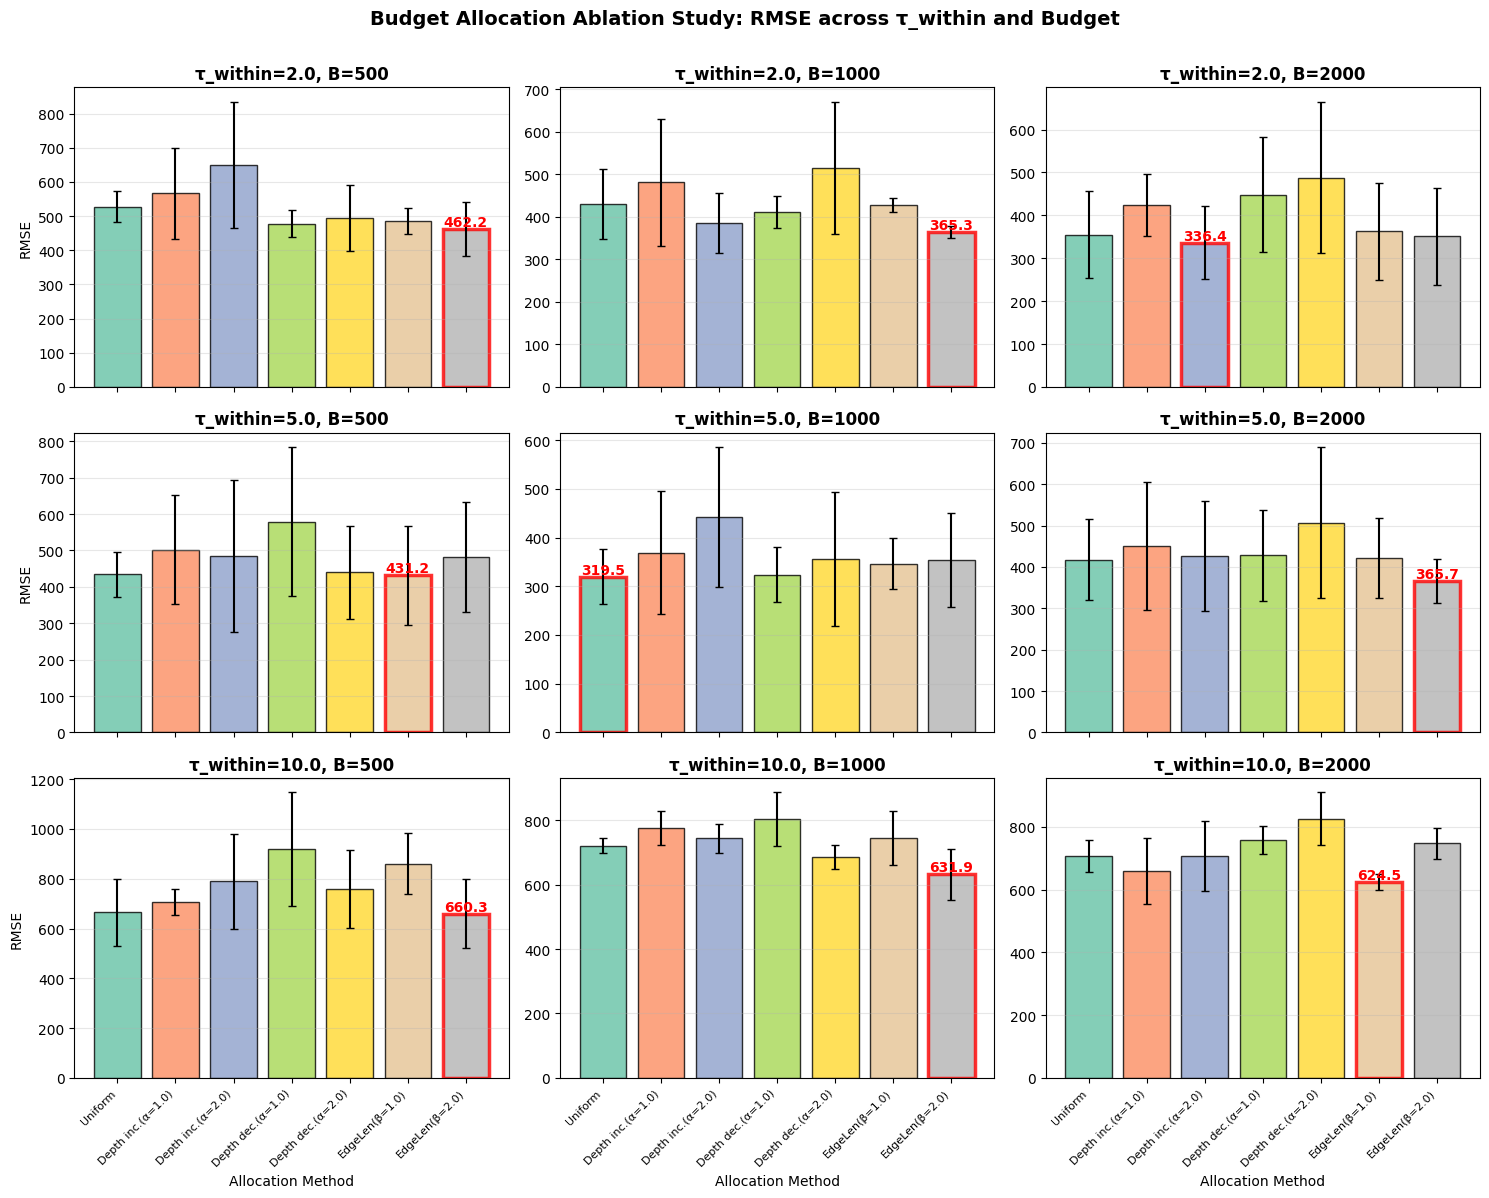

Saved heatmap figure to ablation_budget_allocation_heatmaps.pdf


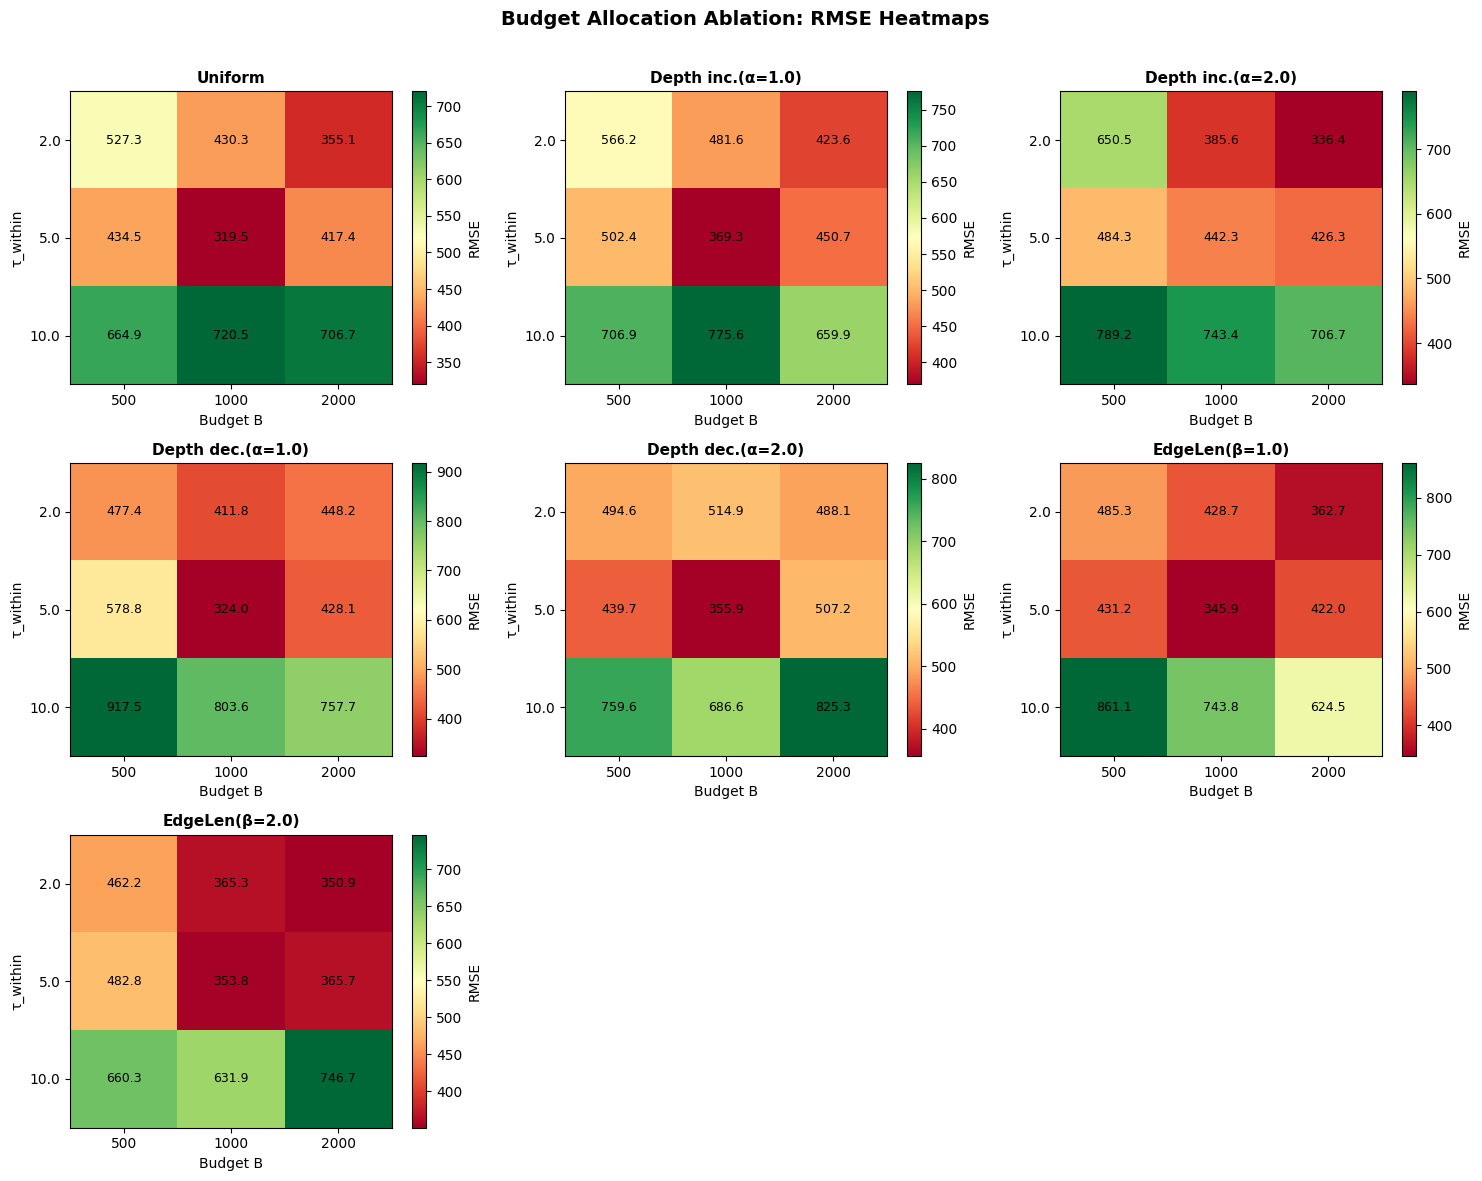

In [14]:
# Print summary table
summarize_ablation_results_sweep(
    results, 
    tau_withins=(2.0, 5.0, 10.0),
    Bs=Bs,
    metric_name='RMSE'
)

# Create grid plot (row=tau, col=B)
plot_ablation_results_sweep(
    results, 
    tau_withins=(2.0, 5.0, 10.0),
    Bs=(500, 1000, 2000),
    metric_name='RMSE',
    save_path="ablation_budget_allocation_grid.pdf"
)

# Create heatmap visualization (optional, alternative view)
plot_ablation_heatmaps(
    results,
    tau_withins=(2.0, 5.0, 10.0),
    Bs=Bs,
    metric_name='RMSE',
    save_path="ablation_budget_allocation_heatmaps.pdf"
)

In [15]:
simplify_table(
    tex_in="final_table.tex",
    tex_out="final_table_family.tex",
)

print("\n✓ Done! Check final_table_family.tex")

 Written final_table_family.tex with 16 data rows

✓ Done! Check final_table_family.tex
